# 附：codes

生成 `01_overview_lec.qmd` 所需的全部模拟图形。

输出图片：

- `limit_dep_intro_fig00_map.png`
- `limit_dep_intro_fig01_continuous_benchmark.png`
- `limit_dep_intro_fig02_binary.png`
- `limit_dep_intro_fig03_ordered.png`
- `limit_dep_intro_fig04_count.png`
- `limit_dep_intro_fig05_corner_solution.png`
- `limit_dep_intro_fig06_censored.png`
- `limit_dep_intro_fig07_truncated.png`
- `limit_dep_intro_fig08_selection.png`
- `limit_dep_intro_fig09_ppml.png`

In [106]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(20260415)
BASE_DIR = Path.cwd()
FIG_DIR = BASE_DIR / 'figs'
DATA_DIR = BASE_DIR / 'data'
FIG_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.20,
    'font.size': 11,
})

BLUE = '#2A6F97'
ORANGE = '#D97B29'
GREEN = '#5C8D5C'
RED = '#C84C5C'
GRAY = '#7A7A7A'

def save_fig(name):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, bbox_inches='tight')
    plt.close()
    return path

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def export_preview(df, filename, n=8):
    df.head(n).to_csv(DATA_DIR / filename, index=False, encoding='utf-8-sig')

## 1. 数据形态总览图

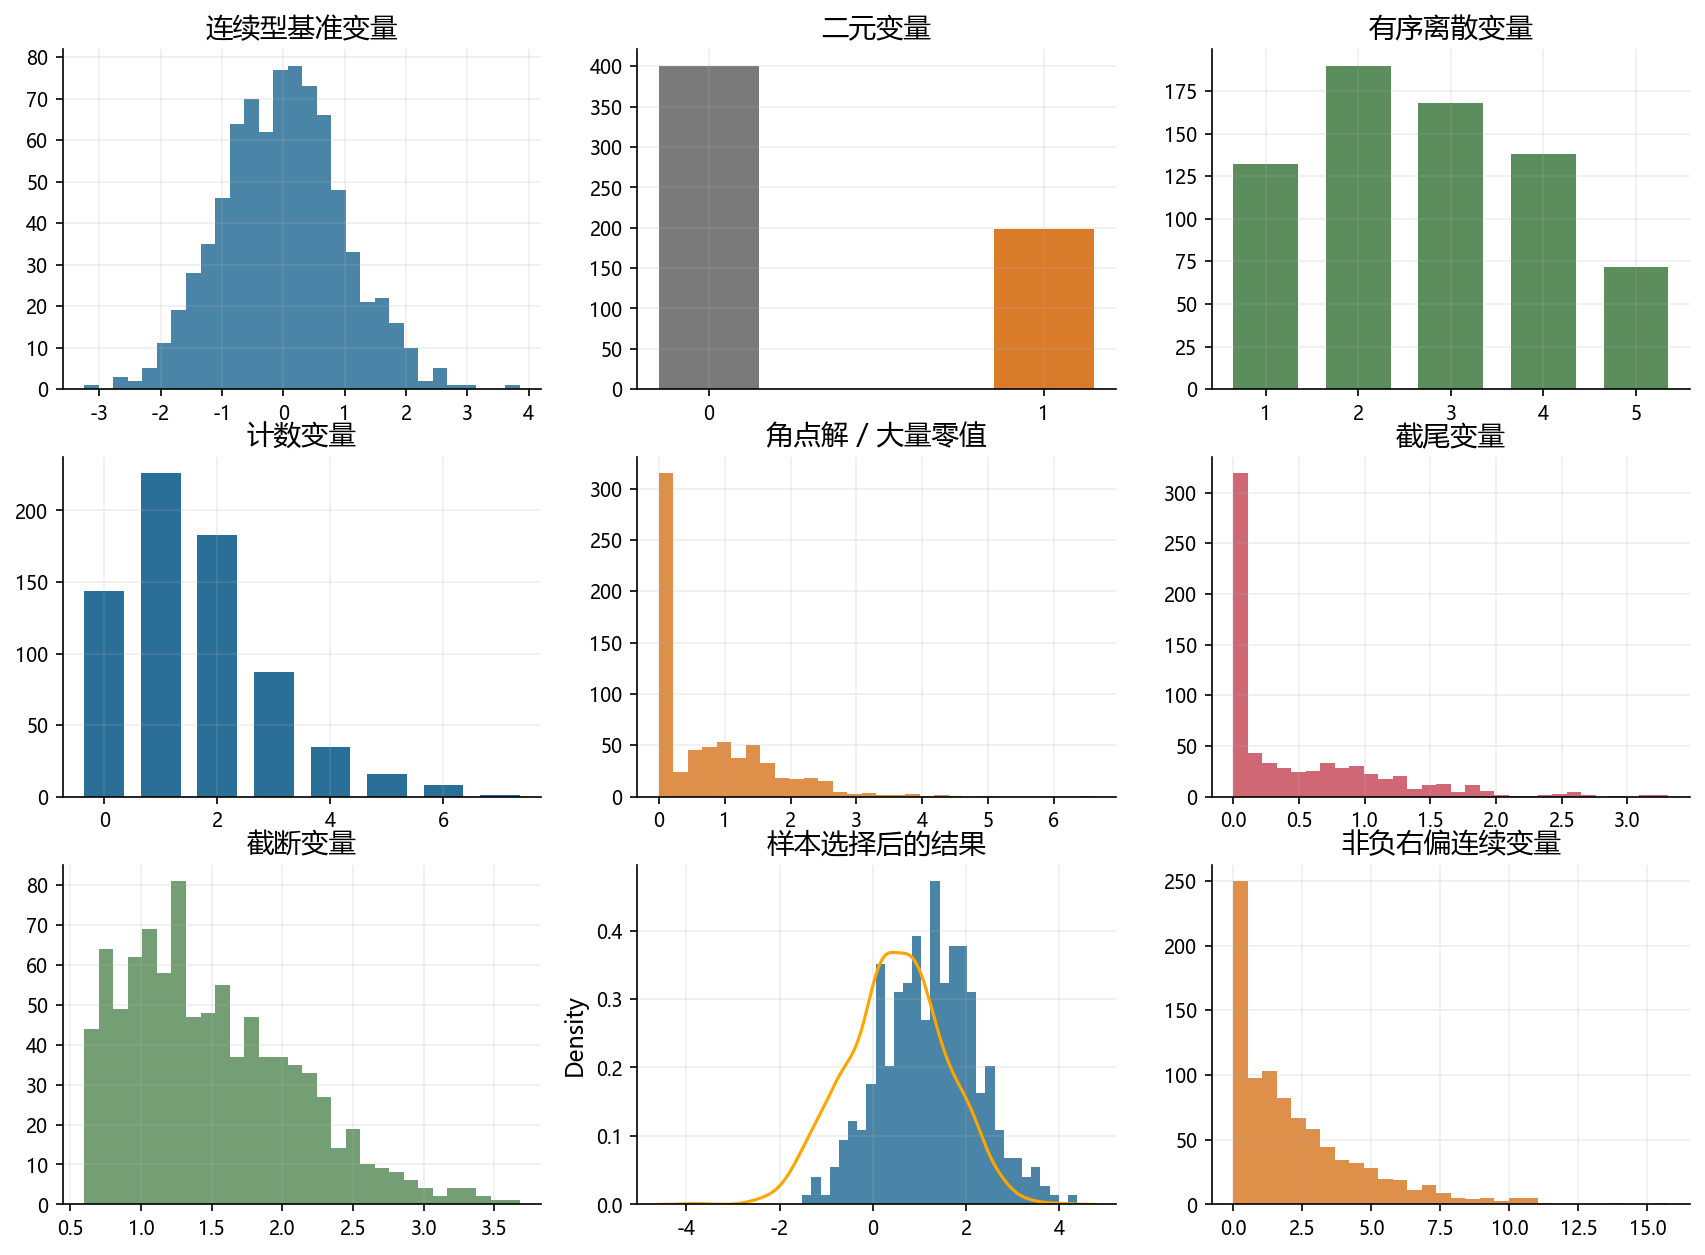

In [ ]:
import seaborn as sns

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.ravel()

seed = 42
np.random.seed(seed)

x = np.random.normal(size=800)
axes[0].hist(x, bins=30, color=BLUE, alpha=0.85)
axes[0].set_title('连续型基准变量')

binary = np.random.binomial(1, 0.32, size=600)
axes[1].bar([0, 1], pd.Series(binary).value_counts().sort_index(), color=[GRAY, ORANGE], width=0.3)
axes[1].set_title('二元变量')
axes[1].set_xticks([0, 1])

ordered = np.random.choice([1, 2, 3, 4, 5], size=700, p=[0.18, 0.29, 0.24, 0.18, 0.11])
axes[2].bar(np.arange(1, 6), pd.Series(ordered).value_counts().sort_index(), color=GREEN, width=0.7)
axes[2].set_title('有序离散变量')

count = np.random.poisson(1.6, size=700)
axes[3].bar(np.arange(0, 8), pd.Series(count).clip(upper=7).value_counts().sort_index().reindex(range(8), fill_value=0), color=BLUE, width=0.7)
axes[3].set_title('计数变量')

corner = np.where(np.random.rand(700) < 0.42, 0, np.random.lognormal(mean=0.2, sigma=0.6, size=700))
axes[4].hist(corner, bins=30, color=ORANGE, alpha=0.85)
axes[4].set_title('角点解 / 大量零值')

latent = np.random.normal(loc=0.2, scale=1.0, size=700)
censored = np.maximum(latent, 0)
axes[5].hist(censored, bins=30, color=RED, alpha=0.85)
axes[5].set_title('截尾变量')

trunc = np.random.normal(1.2, 0.8, size=1200)
trunc = trunc[trunc > 0.6]
axes[6].hist(trunc, bins=30, color=GREEN, alpha=0.85)
axes[6].set_title('截断变量')

selected = np.random.normal(0.5, 1.1, size=1200)
selected = selected[np.random.rand(selected.size) < sigmoid(selected - 1.4)]
#selected 样本的直方图，纵轴为密度
axes[7].hist(selected, bins=30, color=BLUE, alpha=0.85, density=True)
#附加完整样本的核密度函数图
sns.kdeplot(np.random.normal(0.5, 1.1, size=1200), ax=axes[7], color='orange', linestyle='-')
axes[7].set_title('样本选择后的结果')

ppml = np.where(np.random.rand(900) < 0.18, 0, np.random.gamma(shape=1.3, scale=2.2, size=900))
axes[8].hist(ppml, bins=30, color=ORANGE, alpha=0.85)
axes[8].set_title('非负右偏连续变量')

for ax in axes:
    ax.tick_params(axis='both', labelsize=9)

fig.savefig('./figs/limit_dep_intro_fig00_map.png', dpi=300, bbox_inches='tight')

## 2. 各类变量的模拟图形

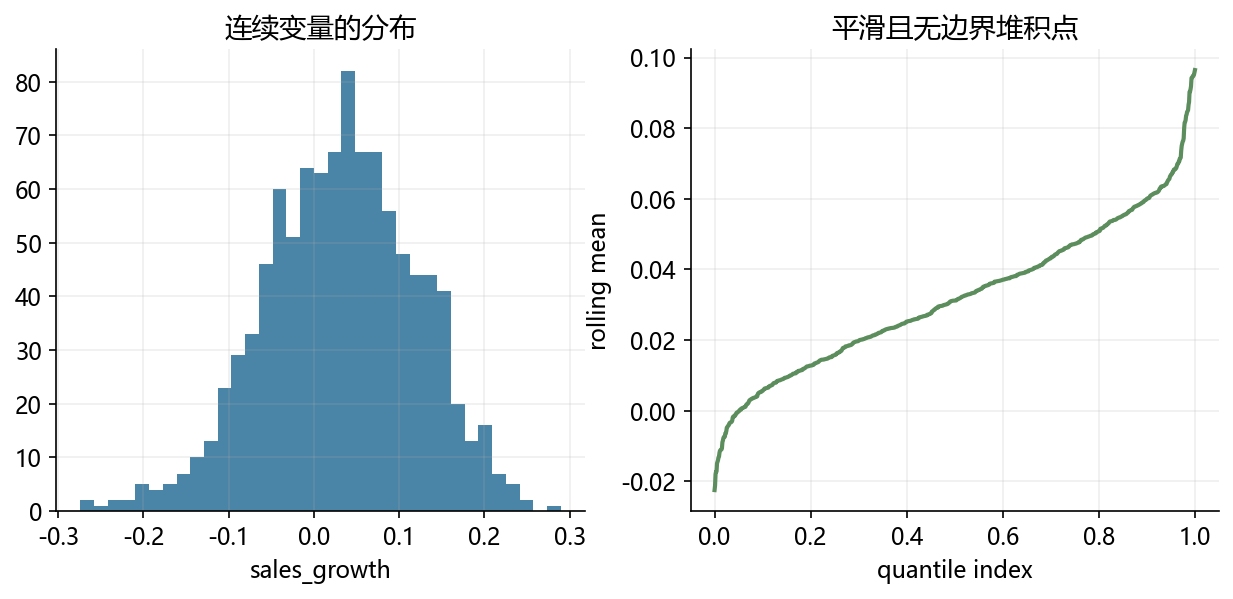

In [117]:
sales_growth = np.random.normal(loc=0.03, scale=0.09, size=1000)
export_preview(pd.DataFrame({'sales_growth': sales_growth}), 'overview_continuous_preview.csv')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(sales_growth, bins=35, color=BLUE, alpha=0.85)
axes[0].set_title('连续变量的分布')
axes[0].set_xlabel('sales_growth')

q = pd.Series(sales_growth).rolling(20).mean().dropna()
axes[1].plot(np.linspace(0, 1, len(q)), np.sort(q), color=GREEN, linewidth=2)
axes[1].set_title('平滑且无边界堆积点')
axes[1].set_xlabel('quantile index')
axes[1].set_ylabel('rolling mean')

fig.savefig('./figs/limit_dep_intro_fig01_continuous_benchmark.png', dpi=300, bbox_inches='tight')

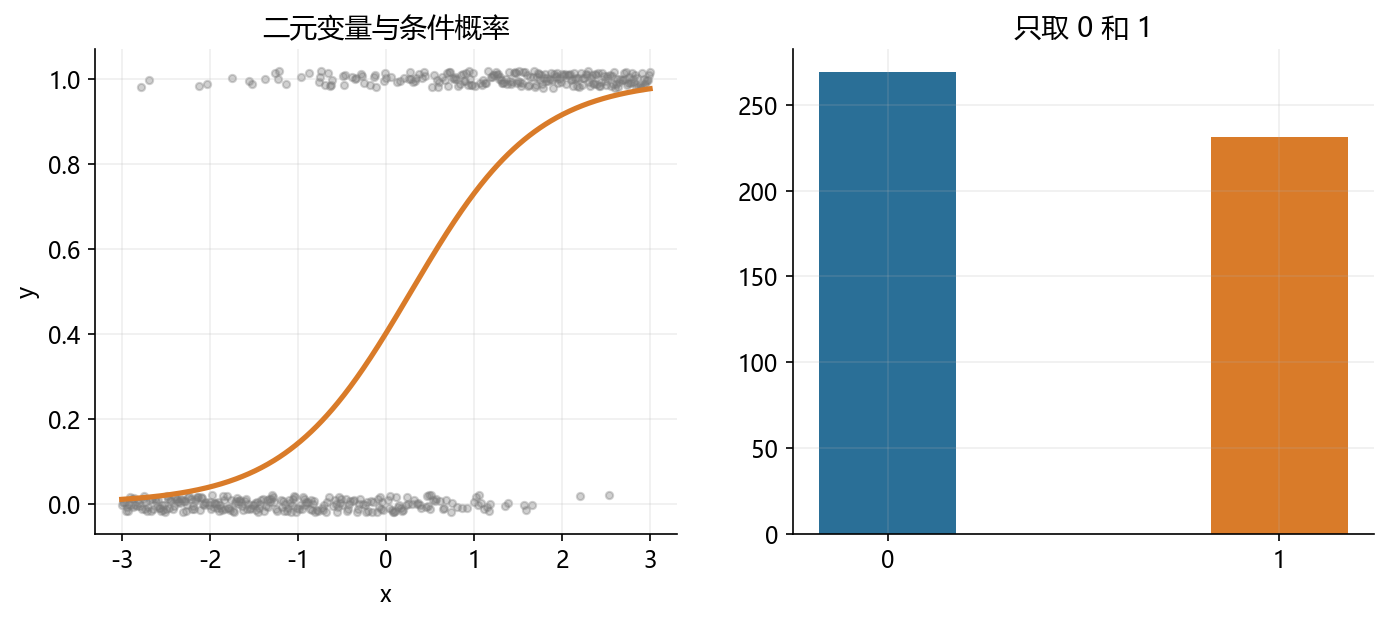

In [118]:
x = np.linspace(-3, 3, 500)
p = sigmoid(1.4 * x - 0.4)
binary_y = np.random.binomial(1, p)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].scatter(x, binary_y + np.random.uniform(-0.02, 0.02, size=x.size), s=12, alpha=0.35, color=GRAY)
axes[0].plot(x, p, color=ORANGE, linewidth=2.5)
axes[0].set_title('二元变量与条件概率')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

freq = pd.Series(binary_y).value_counts().sort_index()
axes[1].bar([0, 1], freq, color=[BLUE, ORANGE], width=0.35)
axes[1].set_xticks([0, 1])
axes[1].set_title('只取 0 和 1')

fig.savefig('./figs/limit_dep_intro_fig02_binary.png', dpi=300, bbox_inches='tight')

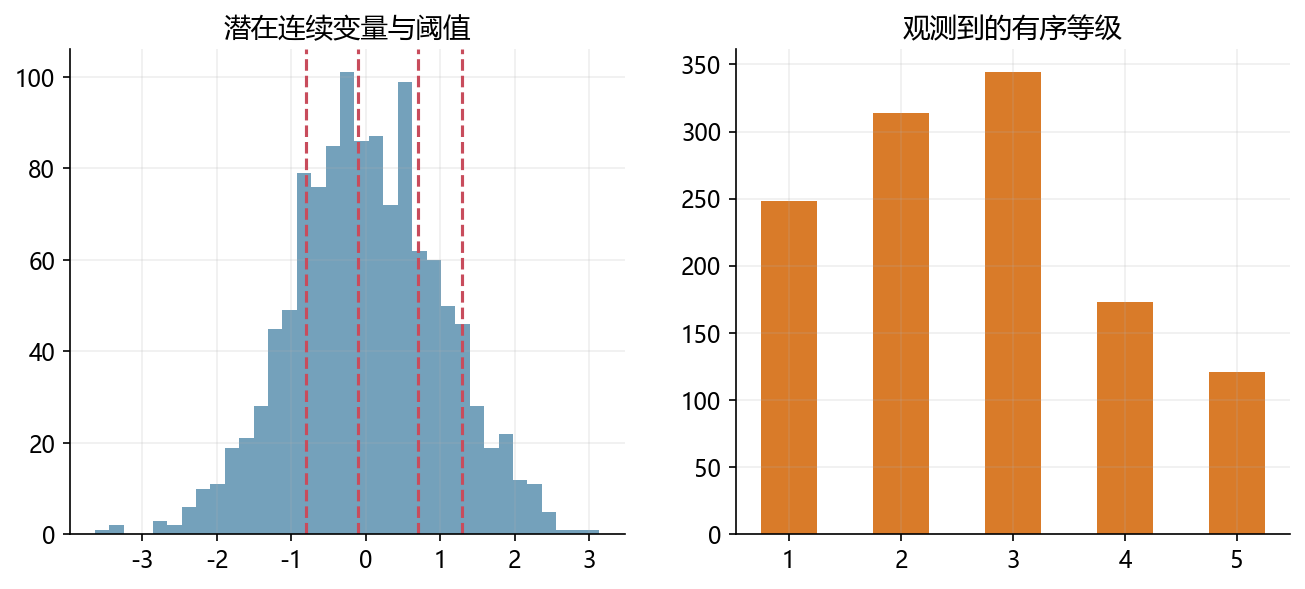

In [ ]:
z = np.random.normal(size=1200)
cuts = [-0.8, -0.1, 0.7, 1.3]
rating = np.digitize(z, cuts) + 1

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
axes[0].hist(z, bins=35, color=BLUE, alpha=0.65)
for c in cuts:
    axes[0].axvline(c, color=RED, linestyle='--', linewidth=1.5)
axes[0].set_title('潜在连续变量与阈值')

counts = pd.Series(rating).value_counts().sort_index()
axes[1].bar(counts.index, counts.values, color=ORANGE, width=0.5)
axes[1].set_title('观测到的有序等级')
axes[1].set_xticks(counts.index)

fig.savefig('./figs/limit_dep_intro_fig03_ordered.png', dpi=300, bbox_inches='tight')

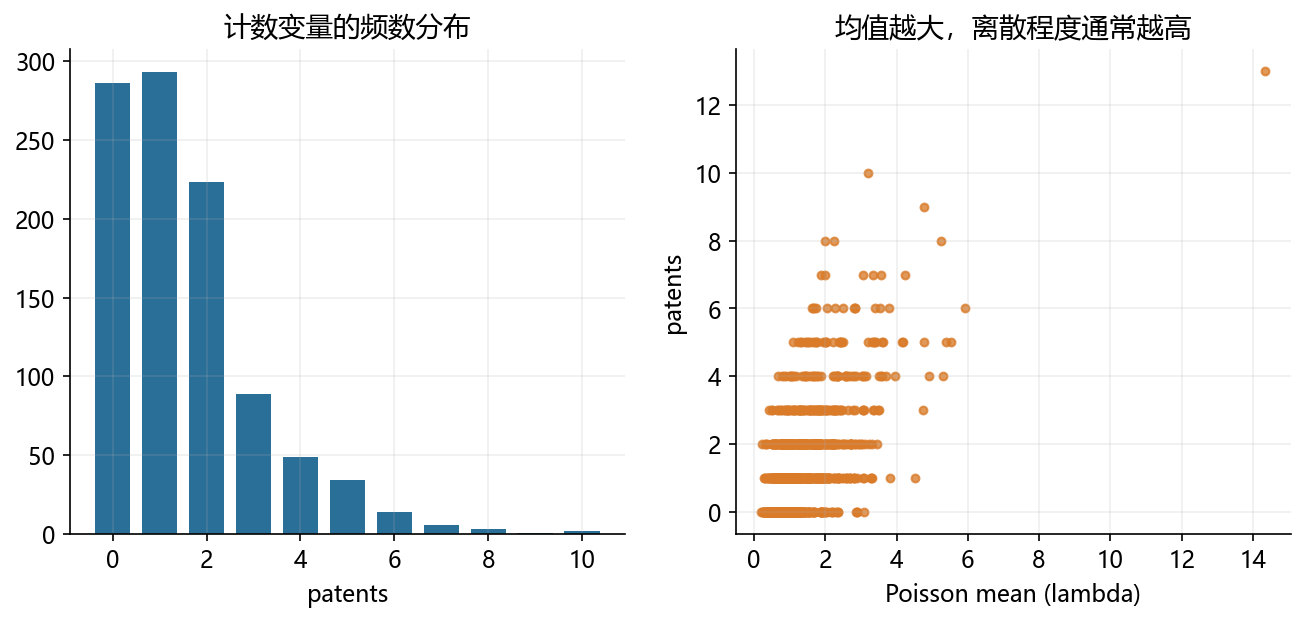

In [ ]:
mu = np.exp(np.random.normal(0.2, 0.55, size=1000))
patents = np.random.poisson(mu)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
count_table = pd.Series(np.clip(patents, 0, 10)).value_counts().sort_index().reindex(range(11), fill_value=0)
axes[0].bar(count_table.index, count_table.values, color=BLUE, width=0.75)
axes[0].set_title('计数变量的频数分布')
axes[0].set_xlabel('patents')

axes[1].scatter(mu, patents, s=14, alpha=0.78, color=ORANGE)
axes[1].set_title('均值越大，离散程度通常越高')
axes[1].set_xlabel('Poisson mean (lambda)')
axes[1].set_ylabel('patents')

fig.savefig('./figs/limit_dep_intro_fig04_count.png', dpi=300, bbox_inches='tight')

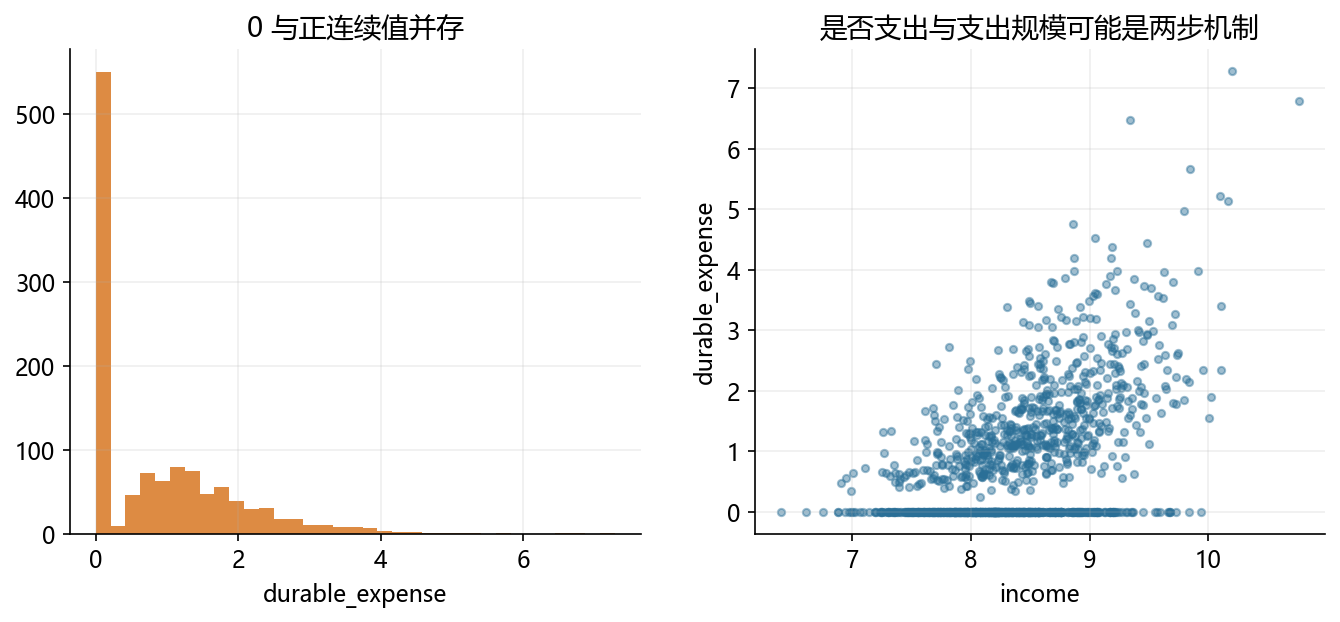

In [ ]:
%matplotlib inline
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt

income = np.random.normal(8.4, 0.6, size=1200)
participate = np.random.binomial(1, sigmoid(income - 8.2))
positive_spend = np.exp(0.55 * (income - 8.0) + np.random.normal(0, 0.45, size=1200))
durable = participate * positive_spend

fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.2))

axes[0].hist(durable, bins=35, color=ORANGE, alpha=0.88)
axes[0].set_title('0 与正连续值并存')
axes[0].set_xlabel('durable_expense')

axes[1].scatter(income, durable, s=12, alpha=0.45, color=BLUE)
axes[1].set_title('是否支出与支出规模可能是两步机制')
axes[1].set_xlabel('income')
axes[1].set_ylabel('durable_expense')

fig.savefig('./figs/limit_dep_intro_fig05_corner_solution.png', dpi=300, bbox_inches='tight')

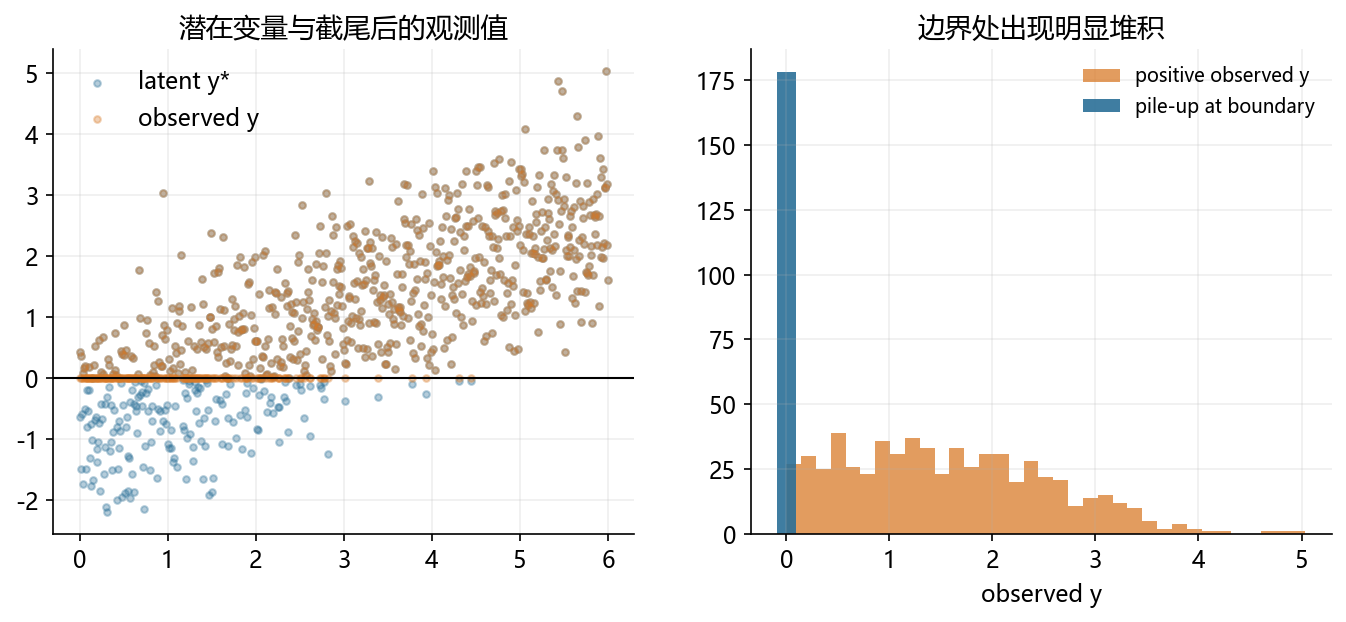

In [ ]:
x = np.linspace(0, 6, 800)
y_latent = -0.8 + 0.62 * x + np.random.normal(0, 0.9, size=x.size)
y_obs = np.maximum(y_latent, 0)
pileup_n = (y_obs == 0).sum()
positive_obs = y_obs[y_obs > 0]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].scatter(x, y_latent, s=10, alpha=0.35, color=BLUE, label='latent y*')
axes[0].scatter(x, y_obs, s=10, alpha=0.35, color=ORANGE, label='observed y')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].legend(frameon=False)
axes[0].set_title('潜在变量与截尾后的观测值')

axes[1].hist(positive_obs, bins=35, color=ORANGE, alpha=0.75, label='positive observed y')
axes[1].bar([0], [pileup_n], width=0.18, color=BLUE, alpha=0.90, label='pile-up at boundary')
axes[1].set_title('边界处出现明显堆积')
axes[1].set_xlabel('observed y')
axes[1].legend(frameon=False, fontsize=9)

fig.savefig('./figs/limit_dep_intro_fig06_censored.png', dpi=300, bbox_inches='tight')


Saved: limit_dep_intro_fig07_truncated.png
总体 N = 4000, 截断后 N = 3059, 损失比例 = 23.5%
总体均值 = 1.79, 截断后均值 = 2.23


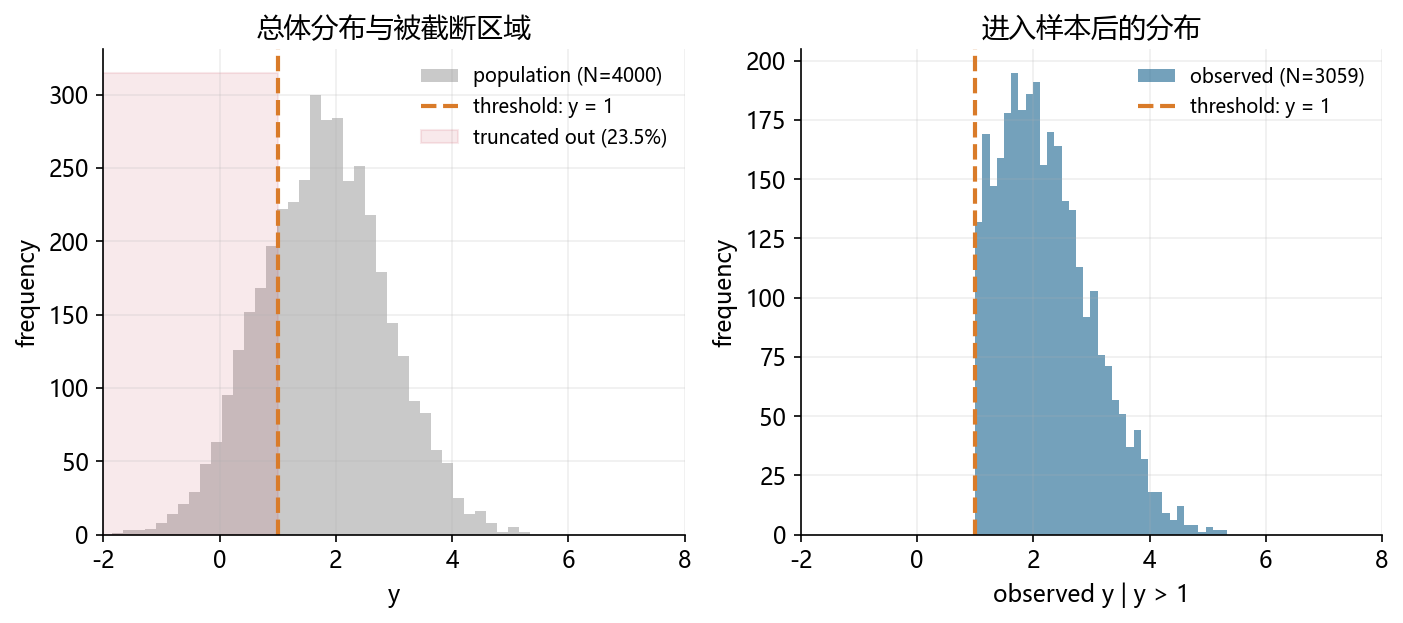

In [ ]:
# 总体：所有企业（含小企业）；截断点：只观察 y > 1 的样本

population = np.random.normal(1.8, 1.1, size=4000)
TRUNC = 1
sample = population[population > TRUNC]
loss_rate = 1 - len(sample) / len(population)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# 左图：总体分布，并标注被截断掉的样本区间
ax = axes[0]
hist_vals = ax.hist(population, bins=40, color=GRAY, alpha=0.40, label=f'population (N={len(population)})')
ax.axvline(TRUNC, color=ORANGE, linestyle='--', linewidth=2, label=f'threshold: y = {TRUNC}')
ymax = hist_vals[0].max() * 1.05
ax.fill_betweenx([0, ymax], -2, TRUNC, color=RED, alpha=0.12, label=f'truncated out ({loss_rate:.1%})')
ax.set_title('总体分布与被截断区域')
ax.set_xlabel('y')
ax.set_ylabel('frequency')
ax.set_xlim(-2, 8)
ax.legend(frameon=False, fontsize=9)

# 右图：进入样本后的分布
ax = axes[1]
ax.hist(sample, bins=35, color=BLUE, alpha=0.65, label=f'observed (N={len(sample)})')
ax.axvline(TRUNC, color=ORANGE, linestyle='--', linewidth=2, label=f'threshold: y = {TRUNC}')
ax.set_title('进入样本后的分布')
ax.set_xlabel('observed y | y > 1')
ax.set_ylabel('frequency')
ax.set_xlim(-2, 8)
ax.legend(frameon=False, fontsize=9)

fig.savefig('./figs/limit_dep_intro_fig07_truncated.png', dpi=300, bbox_inches='tight')

print('Saved: limit_dep_intro_fig07_truncated.png')
print(f'总体 N = {len(population)}, 截断后 N = {len(sample)}, 损失比例 = {loss_rate:.1%}')
print(f'总体均值 = {population.mean():.2f}, 截断后均值 = {sample.mean():.2f}')

Saved: limit_dep_intro_fig08_selection.png
observed 比例: 55.7%
population slope: 0.329 | observed slope: 0.416


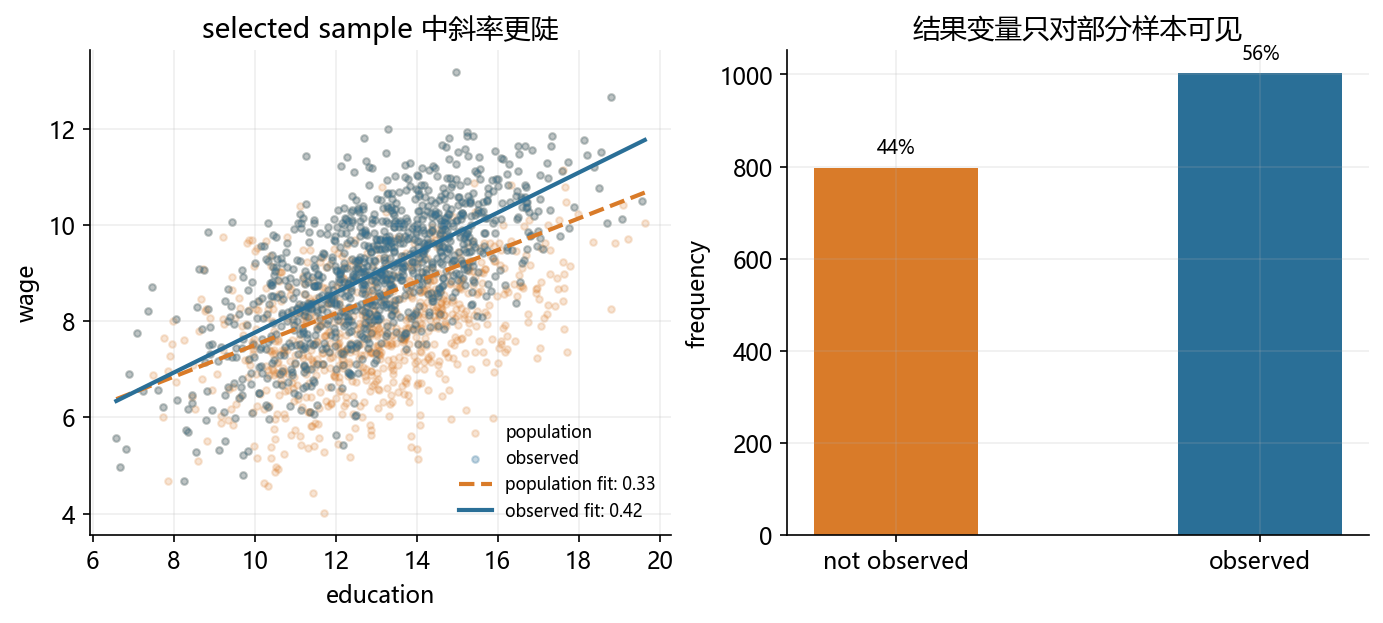

In [ ]:
education = np.random.normal(13, 2.1, size=1800)
ability = np.random.normal(size=1800)
wage_noise = np.random.normal(0, 0.8, size=1800)
select_noise = np.random.normal(0, 1.0, size=1800)
latent_wage = 4.1 + 0.34 * education + 0.9 * ability + wage_noise
selection_index = -0.3 + 0.05 * education + 0.95 * ability + 0.35 * (education - 13) * ability + 0.75 * wage_noise + select_noise
employed = (selection_index > 0).astype(int)
observed_wage = np.where(employed == 1, latent_wage, np.nan)
education_obs = education[employed == 1]
wage_obs = observed_wage[employed == 1]

m_pop = np.polyfit(education, latent_wage, 1)
m_obs = np.polyfit(education_obs, wage_obs, 1)
xs = np.linspace(education.min(), education.max(), 100)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].scatter(education, latent_wage, s=10, alpha=0.20, color=ORANGE, label='population')
axes[0].scatter(education_obs, wage_obs, s=10, alpha=0.28, color=BLUE, label='observed')
axes[0].plot(xs, np.polyval(m_pop, xs), color=ORANGE, linewidth=2, linestyle='--', label=f'population fit: {m_pop[0]:.2f}')
axes[0].plot(xs, np.polyval(m_obs, xs), color=BLUE, linewidth=2, label=f'observed fit: {m_obs[0]:.2f}')
axes[0].set_title('selected sample 中斜率更陡')
axes[0].set_xlabel('education')
axes[0].set_ylabel('wage')
axes[0].legend(frameon=False, fontsize=8)

share = pd.Series(employed).value_counts().sort_index()

axes[1].bar(['not observed', 'observed'], [share.get(0, 0), share.get(1, 0)], color=[ORANGE, BLUE], width=0.45)
axes[1].set_title('结果变量只对部分样本可见')
axes[1].set_ylabel('frequency')

for idx, val in enumerate([share.get(0, 0), share.get(1, 0)]):
    axes[1].text(idx, val + 20, f'{val / len(employed):.0%}', ha='center', va='bottom', fontsize=9)

fig.savefig('./figs/limit_dep_intro_fig08_selection.png', dpi=300, bbox_inches='tight')

print('Saved: limit_dep_intro_fig08_selection.png')
print(f'observed 比例: {employed.mean():.1%}')
print(f'population slope: {m_pop[0]:.3f} | observed slope: {m_obs[0]:.3f}')

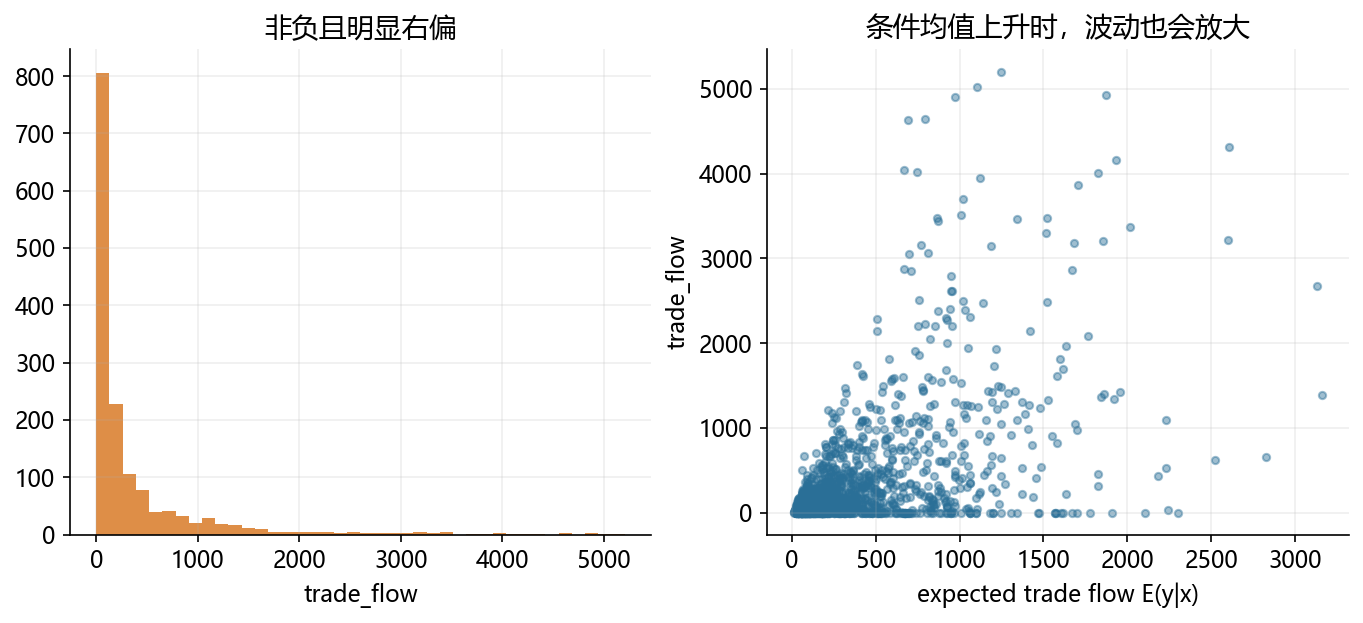

In [ ]:
distance = np.random.uniform(1.0, 6.0, size=1500)
market_size = np.random.normal(22.0, 1.0, size=1500)
expected_trade_flow = np.exp(5.6 + 0.42 * market_size - 0.75 * distance) / 1000
trade_flow = np.where(np.random.rand(1500) < 0.15, 0, np.random.gamma(shape=1.2, scale=np.maximum(expected_trade_flow, 0.1), size=1500))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].hist(trade_flow, bins=40, color=ORANGE, alpha=0.86)
axes[0].set_title('非负且明显右偏')
axes[0].set_xlabel('trade_flow')
axes[1].scatter(expected_trade_flow, trade_flow, s=12, alpha=0.45, color=BLUE)
axes[1].set_title('条件均值上升时，波动也会放大')
axes[1].set_xlabel('expected trade flow E(y|x)')
axes[1].set_ylabel('trade_flow')

fig.savefig('./figs/limit_dep_intro_fig09_ppml.png', dpi=300, bbox_inches='tight')
